<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_11_KNN_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 11 — K-Nearest Neighbors Classification Model

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 11 is to train and evaluate a K-Nearest Neighbors
(KNN) classification model for predicting student performance categories.

KNN is a distance-based algorithm. Therefore, this day will also introduce
feature scaling into the preprocessing pipeline.

### Today's Work

- Load the dataset independently.
- Recreate the project target.
- Prevent target leakage.
- Prepare numerical, ordinal and categorical features.
- Perform a stratified train-test split.
- Apply one-hot encoding to categorical features.
- Apply feature scaling to numerical features.
- Train a KNN classifier.
- Generate predictions.
- Evaluate the model.
- Analyze the confusion matrix.
- Compare KNN with previous baseline models.
- Save the model comparison results.

No hyperparameter tuning will be performed today.

In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y_original = student_performance.data.targets

df = X.copy()
df["G3"] = y_original["G3"]

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (649, 31)


In [3]:
def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(
    performance_category
)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [4]:
target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (649, 31)
Target shape: (649,)

Target distribution:
performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [5]:
X_model = X.drop(columns=["G3"])

print("G3 present in model features:", "G3" in X_model.columns)
print("Final model feature count:", X_model.shape[1])

G3 present in model features: False
Final model feature count: 30


In [6]:
numerical_features = [
    "age",
    "absences"
]

ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

binary_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

nominal_features = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

categorical_features = (
    binary_features +
    nominal_features
)

print("Numerical features:", len(numerical_features))
print("Ordinal features:", len(ordinal_features))
print("Categorical features:", len(categorical_features))

Numerical features: 2
Ordinal features: 11
Categorical features: 17


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


## Why Scaling Is Required for KNN

KNN calculates distances between observations.

Features with larger numerical ranges can have a stronger influence on
distance calculations.

For example, `absences` can have a much larger numerical range than some
rating-style features.

Therefore, numerical and ordinal features will be standardized before KNN
uses them.

The scaling operation will be placed inside the Scikit-learn Pipeline so that
the scaler is fitted only on the training data.

In [8]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

numerical_scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            numerical_scaler,
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("KNN preprocessing pipeline created.")

KNN preprocessing pipeline created.


In [9]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("KNN classifier created successfully.")
print("Number of neighbors:", knn_model.n_neighbors)

KNN classifier created successfully.
Number of neighbors: 5


In [10]:
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", knn_model)
    ]
)

print("Complete KNN pipeline created successfully.")

Complete KNN pipeline created successfully.


In [11]:
knn_pipeline.fit(
    X_train,
    y_train
)

print("KNN model trained successfully.")

KNN model trained successfully.


In [12]:
y_pred = knn_pipeline.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
['Medium' 'Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium' 'Medium'
 'Medium' 'Low' 'High' 'High' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium'
 'Medium' 'Medium' 'Medium']


In [13]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_comparison.head(20)

,Actual,Predicted
0,Medium,Medium
1,Low,Medium
2,Medium,Medium
3,Low,Medium
4,Medium,Low
5,Medium,Medium
6,High,Medium
7,Medium,Medium
8,Medium,Medium
9,Low,Low


In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("KNN Accuracy:", round(accuracy, 4))
print("KNN Accuracy (%):", round(accuracy * 100, 2))

KNN Accuracy: 0.6385
KNN Accuracy (%): 63.85


In [15]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("KNN Macro Precision:", round(precision, 4))

KNN Macro Precision: 0.5523


In [16]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("KNN Macro F1:", round(f1, 4))

KNN Macro F1: 0.4931


In [18]:
recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

knn_results = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

knn_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,KNN,0.638462,0.552284,0.472527,0.493093


In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       0.50      0.25      0.33        20
      Medium       0.68      0.82      0.75        84
        High       0.47      0.35      0.40        26

    accuracy                           0.64       130
   macro avg       0.55      0.47      0.49       130
weighted avg       0.61      0.64      0.61       130



In [20]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 5 15  0]
 [ 5 69 10]
 [ 0 17  9]]


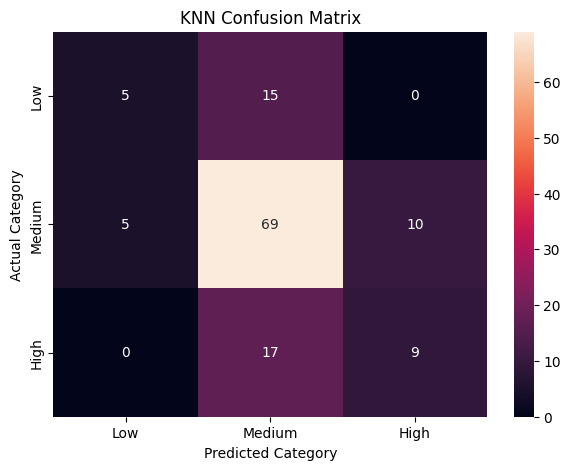

In [21]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [22]:
y_train_pred = knn_pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

Training Accuracy: 0.7148
Testing Accuracy: 0.6385


In [23]:
accuracy_gap = train_accuracy - test_accuracy

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Gap:", round(accuracy_gap, 4))

Training Accuracy: 0.7148
Testing Accuracy: 0.6385
Accuracy Gap: 0.0764


In [24]:
print("Actual test distribution:")
print(y_test.value_counts())

print("\nPredicted distribution:")
print(pd.Series(y_pred).value_counts())

Actual test distribution:
performance_category
Medium    84
High      26
Low       20
Name: count, dtype: int64

Predicted distribution:
Medium    101
High       19
Low        10
Name: count, dtype: int64


In [25]:
probabilities = knn_pipeline.predict_proba(X_test)

print("Probability matrix shape:", probabilities.shape)

print("\nFirst 5 probability predictions:")
print(probabilities[:5])

Probability matrix shape: (130, 3)

First 5 probability predictions:
[[0.  0.2 0.8]
 [0.2 0.2 0.6]
 [0.4 0.  0.6]
 [0.  0.2 0.8]
 [0.  0.8 0.2]]


In [26]:
classes = knn_pipeline.named_steps[
    "classifier"
].classes_

print("Class order:")
print(classes)

Class order:
['High' 'Low' 'Medium']


In [27]:
prediction_confidence = probabilities.max(axis=1)

confidence_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Confidence": prediction_confidence
})

confidence_df.head(10)

,Actual,Predicted,Confidence
0,Medium,Medium,0.8
1,Low,Medium,0.6
2,Medium,Medium,0.6
3,Low,Medium,0.8
4,Medium,Low,0.8
5,Medium,Medium,0.8
6,High,Medium,0.8
7,Medium,Medium,0.6
8,Medium,Medium,0.8
9,Low,Low,0.6


In [28]:
confidence_df.sort_values(
    by="Confidence",
    ascending=False
).head(10)

,Actual,Predicted,Confidence
17,Medium,Medium,1.0
14,Medium,Medium,1.0
100,Medium,Medium,1.0
109,Medium,Medium,1.0
30,High,Medium,1.0
28,Medium,Medium,1.0
24,Medium,Medium,1.0
20,Medium,Medium,1.0
19,Medium,Medium,1.0
18,Medium,Medium,1.0


In [29]:
confidence_df.sort_values(
    by="Confidence",
    ascending=True
).head(10)

,Actual,Predicted,Confidence
21,Medium,Low,0.4
25,Medium,High,0.4
23,Medium,Low,0.4
34,High,High,0.4
38,Medium,High,0.4
90,Low,Low,0.4
92,Medium,Low,0.4
75,Low,Low,0.4
127,Medium,High,0.4
113,Medium,High,0.4


In [31]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "categorical",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        ),
                        categorical_features
                    ),
                    (
                        "numerical",
                        "passthrough",
                        numerical_features + ordinal_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)
logistic_pred = logistic_pipeline.predict(X_test)

In [33]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "categorical",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        ),
                        categorical_features
                    ),
                    (
                        "numerical",
                        "passthrough",
                        numerical_features + ordinal_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)
decision_tree_pred = decision_tree_pipeline.predict(X_test)

In [34]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "categorical",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        ),
                        categorical_features
                    ),
                    (
                        "numerical",
                        "passthrough",
                        numerical_features + ordinal_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)
random_forest_pred = random_forest_pipeline.predict(X_test)

In [35]:
def calculate_metrics(model_name, y_true, predictions):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Macro Precision": precision_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        )
    }


model_comparison = pd.DataFrame([
    calculate_metrics(
        "Logistic Regression",
        y_test,
        logistic_pred
    ),
    calculate_metrics(
        "Decision Tree",
        y_test,
        decision_tree_pred
    ),
    calculate_metrics(
        "Random Forest",
        y_test,
        random_forest_pred
    ),
    calculate_metrics(
        "KNN",
        y_test,
        y_pred
    )
])

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,Decision Tree,0.530769,0.446826,0.463919,0.450885
2,Random Forest,0.623077,0.437098,0.355678,0.327929
3,KNN,0.638462,0.552284,0.472527,0.493093


In [36]:
model_comparison_rounded = model_comparison.copy()

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

model_comparison_rounded[metric_columns] = (
    model_comparison_rounded[metric_columns].round(4)
)

model_comparison_rounded

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.6692,0.5999,0.5076,0.5106
1,Decision Tree,0.5308,0.4468,0.4639,0.4509
2,Random Forest,0.6231,0.4371,0.3557,0.3279
3,KNN,0.6385,0.5523,0.4725,0.4931


In [37]:
model_ranking = model_comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

model_ranking.insert(
    0,
    "Rank",
    range(1, len(model_ranking) + 1)
)

model_ranking

,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,2,KNN,0.638462,0.552284,0.472527,0.493093
2,3,Decision Tree,0.530769,0.446826,0.463919,0.450885
3,4,Random Forest,0.623077,0.437098,0.355678,0.327929


In [39]:
best_model_index = model_comparison["Macro F1"].idxmax()

best_model = model_comparison.loc[
    best_model_index,
    "Model"
]

best_f1 = model_comparison.loc[
    best_model_index,
    "Macro F1"
]

print("Current best model:", best_model)
print("Best Macro F1:", round(best_f1, 4))

Current best model: Logistic Regression
Best Macro F1: 0.5106


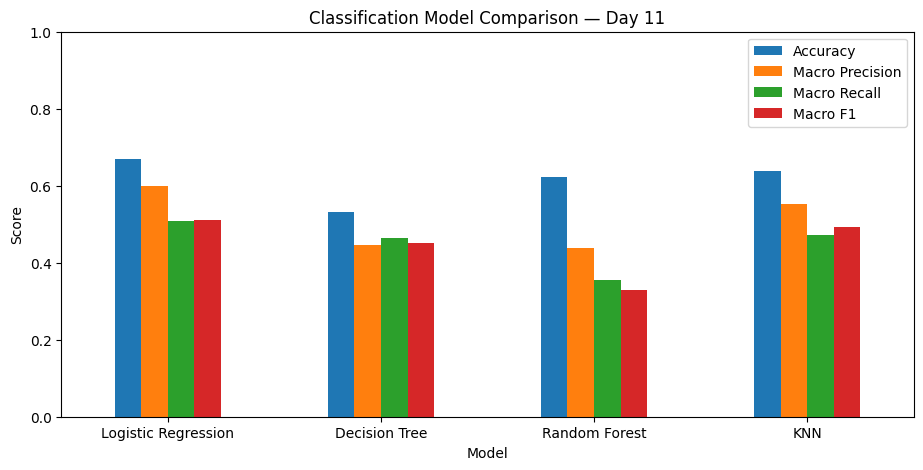

In [40]:
comparison_plot = model_comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Classification Model Comparison — Day 11")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [41]:
knn_f1 = model_comparison.loc[
    model_comparison["Model"] == "KNN",
    "Macro F1"
].iloc[0]

print("KNN Macro F1:", round(knn_f1, 4))
print("Current Best Macro F1:", round(best_f1, 4))

if knn_f1 > best_f1:
    print("KNN currently has the highest Macro F1.")
elif knn_f1 == best_f1:
    print("KNN is tied for the highest Macro F1.")
else:
    print("Another model currently has a higher Macro F1 than KNN.")

KNN Macro F1: 0.4931
Current Best Macro F1: 0.5106
Another model currently has a higher Macro F1 than KNN.


In [42]:
model_ranking.to_csv(
    "day_11_model_comparison.csv",
    index=False
)

print("Day 11 model comparison saved successfully.")

Day 11 model comparison saved successfully.


In [43]:
print("=" * 60)
print("DAY 11 KNN MODEL CHECK")
print("=" * 60)

print("Model tested:", "KNN")
print("Number of neighbors:", 5)

print("\nTraining Accuracy:",
      round(train_accuracy, 4))

print("Testing Accuracy:",
      round(test_accuracy, 4))

print("Macro Precision:",
      round(precision, 4))

print("Macro Recall:",
      round(recall, 4))

print("Macro F1:",
      round(f1, 4))

print("\nCurrent best model by Macro F1:",
      best_model)

print("Best Macro F1:",
      round(best_f1, 4))

print("\nG3 leakage removed:",
      "G3" not in X_model.columns)

print("\nFeature scaling applied:",
      True)

print("\nDay 11 completed successfully.")


DAY 11 KNN MODEL CHECK
Model tested: KNN
Number of neighbors: 5

Training Accuracy: 0.7148
Testing Accuracy: 0.6385
Macro Precision: 0.5523
Macro Recall: 0.4725
Macro F1: 0.4931

Current best model by Macro F1: Logistic Regression
Best Macro F1: 0.5106

G3 leakage removed: True

Feature scaling applied: True

Day 11 completed successfully.


# Day 11 — KNN Findings

## Model Selection

A K-Nearest Neighbors (KNN) classifier was introduced as the fourth
classification algorithm in the project.

KNN is a distance-based algorithm that predicts a class using neighboring
observations.

## Feature Scaling

Feature scaling was introduced specifically for the KNN experiment.

Numerical and ordinal features were standardized using `StandardScaler`.

The scaler was included inside the Scikit-learn Pipeline so that it was
fitted only on the training data.

This prevents information from the test dataset from influencing the
scaling process.

## Categorical Features

Categorical variables were converted using One-Hot Encoding before being
passed to the KNN classifier.

## Evaluation

The KNN model was evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1 Score
- Classification Report
- Confusion Matrix

## Model Comparison

KNN was compared with:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN

The same train-test split and evaluation metrics were used for all models.

## Target Leakage

The `G3` feature was excluded because the project target
`performance_category` is directly derived from `G3`.

Therefore, the model does not receive direct information about the target.

## Conclusion

Day 11 introduced a distance-based machine learning approach and demonstrated
why feature scaling is important for algorithms based on distance.

The KNN baseline will be retained for comparison with the other models.

No hyperparameter tuning was performed today.

# DAY 11 DEVELOPMENT LOG

## Work Completed

- Created an independent Day 11 notebook.
- Loaded the Student Performance dataset.
- Recreated the project target.
- Removed `G3` to prevent target leakage.
- Defined numerical, ordinal and categorical feature groups.
- Performed a stratified train-test split.
- Created a One-Hot Encoder.
- Added StandardScaler for numerical and ordinal features.
- Created the KNN classifier.
- Used `n_neighbors=5` as the baseline configuration.
- Integrated preprocessing and KNN into one pipeline.
- Trained the KNN model.
- Generated predictions.
- Calculated accuracy.
- Calculated macro precision.
- Calculated macro recall.
- Calculated macro F1 score.
- Generated a classification report.
- Generated a confusion matrix.
- Compared training and testing accuracy.
- Examined prediction confidence.
- Recreated previous baseline models.
- Compared four classification algorithms.
- Ranked the models using Macro F1.
- Saved the model comparison results.

## Key Learning

KNN is sensitive to feature scale because it relies on distance calculations.

Standardization is therefore important when features have different numerical
ranges.

## Important Project Decision

Feature scaling will be used for distance-based algorithms such as KNN while
the original preprocessing approach will continue to be used for tree-based
models.

## Next Step

Day 12 will continue the baseline model experimentation before moving into
cross-validation and systematic hyperparameter tuning.